In [1]:
module('load', 'pytorch/gpu-cuda-12.1/2.2.0')

Loading pytorch/gpu-cuda-12.1/2.2.0
  Loading requirement: cuda/12.1 cudnn/8.9.2


In [2]:
import numpy as np
from shared_utils import units
import astropy.units as u
from shared_utils import recursive_to_tensor
import torch
from deep_learning import ResNet50
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(num_classes=2).to(device)
#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochPatienceNight/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-01_14-59-45.pth", map_location=device)
#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochFFT/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-04_13-33-39.pth", map_location=device)
ckpt = torch.load("../../trained_classifiers/RUN2clusterEpochFFT/3_min_mass_10e8_6/checkpoints/LAST_checkpoint_epoch_18_2025-08-04_20-14-56.pth", map_location=device)

#ckpt = torch.load("../../trained_classifiers/RUN1clusterEpochFFT/3_min_mass_10e8_6/checkpoints/checkpoint_epoch_5_2025-08-04_12-42-32.pth", map_location=device)

state_dict = ckpt["model_state_dict"]
new_state = OrderedDict()
for k, v in state_dict.items():
    name = k.replace("module.", "")  # remove `module.` if present
    new_state[name] = v

# 4) load weights into your model (don’t reassign!)
missing, unexpected = model.load_state_dict(new_state, strict=False)
print("missing keys:", missing)
print("unexpected keys:", unexpected)
model.eval()

from abc import ABC, abstractmethod
class ImgLastProc(ABC):
    @abstractmethod
    def __call__(self, imgs : torch.Tensor)-> torch.Tensor:
        # here we have imgs bacause we are intedned to always work with batches at this stage
        pass
class Normalizer(ImgLastProc):
    def __call__(self, imgs : torch.Tensor)-> torch.Tensor:
        max_val = imgs.amax(dim=(2, 3), keepdim=True)
        imgs = imgs / max_val

        return imgs
    
class AstroNormalizer(ImgLastProc):
    def __call__(self, imgs):
    # Your data is naturally zero-centered, so only scale by std
        return imgs / 4.24e-17 
    
    
from noise_applicator.noisers.base_noiser import EuclidNoiserInterfPSF, OnlyInterfPSF

normalizer = AstroNormalizer()
noiser= EuclidNoiserInterfPSF()

cpu
missing keys: []
unexpected keys: []
The PthPSF is loaded as it is. All the physical considerations must be done building it.


In [3]:
import torch

def fit_relu_mle_batch(x: torch.Tensor, Y: torch.Tensor):
    """
    x: (T,)        sorted abscissae
    Y: (T, H, W)   observations per pixel
    returns (A, M, B) each of shape (H, W)
    """
    T, H, W = Y.shape
    device = Y.device

    # 1) prefix sums of x and x^2
    ps_x  = torch.cat([torch.zeros(1, device=device), x.cumsum(0)], dim=0)     # (T+1)
    ps_x2 = torch.cat([torch.zeros(1, device=device), (x*x).cumsum(0)], dim=0) # (T+1)

    # 2) prefix sums of y, y^2, and x*y along dim=0
    Y2 = Y*Y
    XY = x.view(T,1,1) * Y

    ps_y  = torch.cat([torch.zeros(1,H,W,device=device), Y.cumsum(0)],  dim=0)  # (T+1,H,W)
    ps_y2 = torch.cat([torch.zeros(1,H,W,device=device), Y2.cumsum(0)], dim=0)
    ps_xy = torch.cat([torch.zeros(1,H,W,device=device), XY.cumsum(0)], dim=0)

    S_tot_y   = ps_y[-1]   # (H,W)
    S_Y2_tot  = ps_y2[-1]  # (H,W)

    # 3) build interval‐wise scalars (i = 0..T-2)
    i       = torch.arange(0, T-1, device=device)        # (T-1)
    N_less  = (i+1).view(-1,1,1)                         # (T-1,1,1)
    N_ge    = (T - (i+1)).view(-1,1,1)                   # (T-1,1,1)

    S_A_x   = (ps_x[-1]  - ps_x[i+1]).view(-1,1,1)       # (T-1,1,1)
    S_A_x2  = (ps_x2[-1] - ps_x2[i+1]).view(-1,1,1)

    S_A_y   = ps_y[-1].unsqueeze(0)  - ps_y[i+1]         # (T-1,H,W)
    S_A_xy  = ps_xy[-1].unsqueeze(0) - ps_xy[i+1]

    # 4) OLS slope m_i and intercept root‐for‐a
    denom   = N_ge*S_A_x2 - S_A_x**2
    m_i     = (N_ge*S_A_xy - S_A_x*S_A_y) / denom

    a_star  = (
        S_A_x
        - (T*S_A_y - N_ge*S_tot_y) / (m_i * N_less)
    ) / N_ge

    # 5) mask out any a_star outside its [x_i, x_{i+1}] interval
    x_i     = x[:-1].view(-1,1,1)
    x_ip1   = x[1:].view(-1,1,1)
    valid   = (a_star > x_i) & (a_star < x_ip1)

    # 6) corresponding b*
    b_star  = (S_tot_y/T) - (m_i/T)*(S_A_x - N_ge*a_star)

    # 7) assemble SSE in closed form:
    S_A_xy_shift = S_A_xy - a_star*S_A_y
    S_A_x_shift  = S_A_x  - N_ge*a_star
    S_A_shift2   = S_A_x2 - 2*a_star*S_A_x + N_ge*a_star*a_star

    SSE = (
        S_Y2_tot.unsqueeze(0)
        - 2*b_star*S_tot_y.unsqueeze(0)
        - 2*m_i*S_A_xy_shift
        + T*b_star*b_star
        + 2*b_star*m_i*S_A_x_shift
        + (m_i*m_i)*S_A_shift2
    )

    # 8) ignore invalid intervals
    SSE = torch.where(valid, SSE, torch.tensor(float('inf'), device=device))

    # 9) pick best i per pixel
    best_i = SSE.argmin(dim=0)        # (H,W)

    # 10) gather a, m, b at best_i
    grid_h, grid_w = torch.meshgrid(
        torch.arange(H, device=device),
        torch.arange(W, device=device),
        indexing='ij'
    )
    A = a_star[best_i,       grid_h, grid_w]
    M = m_i   [best_i,       grid_h, grid_w]
    B = b_star[best_i,       grid_h, grid_w]

    return A, M, B



In [4]:
import tqdm
import torch.nn.functional as F
from lensing_system import LensModel as LensModelNonBatched
from lensing_system_broadcasting import LensModel
from lensing_system_broadcasting import SourceModel

from noise_applicator import NoiseApplicator, GaussKernel
from shared_utils.physics_relations import r_max_moline
from deep_learning import DeflectionFieldDataset, custom_dataloader, NoNoiseDataset
import matplotlib.pyplot as plt

sub_dict = {
    "type": "NFW",
    "is_substructure": True,
    "params": {
        "pos": [
            1.1963320503127761e-05,
            -7.479630767193157e-06
        ],
        "mass_max": 1.8308882432e10,      # 18308882432.0
        "r_max_kpc": 14.0805025100708,
        "redshift": float('inf')         # extracted as inf
    }
}

from shared_utils import _grid_lens
eval_grid=_grid_lens(8.0, 30, device="cuda")

class SensMapMaker:
    def __init__(
        self,
        substructure_dict=sub_dict,
        sub_key_changed="mass_max", # this is not really flexible, as we change the concentration accordingly
        catalog_name = "NOSUB_cat",
        values_key = 10**torch.linspace(7.,11., 14),
        evaluation_grid=eval_grid,
        image_grid_npix = 80,
        image_grid_size = 8.0,
        upsampling =5,
        model=model,
        batch_size=1024,
        sample_index = 0,
        noiser = noiser
    ):
        self.image_grid=_grid_lens(image_grid_size, image_grid_npix*upsampling, device="cuda")
        self.evaluation_grid=evaluation_grid
        self.batch_size=batch_size
        self.model=model.to("cuda")
        self.values_key = values_key
        self.noiser = noiser
        self.upsampling = upsampling

        dataset = DeflectionFieldDataset(
            catalog_name = catalog_name,
            grid_width_arcsec=8.0,
            grid_pixel_side=80,
            upscaling=upsampling,
            broadcasting=True,
            samples_used='all'
        )
        deflection_batch, batch_data = dataset.get_batch([sample_index])

        # Extract the single sample from the batch
        base_deflection = deflection_batch[0]
        #self.source_redshift = main_lens_dict["source_model"]["params"]["redshift"]
        self.base_deflection = base_deflection.unsqueeze(0).repeat(batch_size, 1, 1, 1)
        #for the source data and precomputed data we need to do the same
        precomp = batch_data['precomputed_data']
        self.precomp = self.process_precomp_data(precomp, batch_size=batch_size)
        source_data = batch_data['source_data']
        self.source_data = self.process_source_data(source_data, batch_size=batch_size)

        self.sub_raw=substructure_dict
        self.set_sub_params_matrix(evaluation_grid, sub_key_changed, values_key)
        self.source_model=SourceModel(self.source_data, self.precomp)
        image=self.source_model(self.base_deflection)
        print(image.shape)
        
        print(image.shape)
        import matplotlib.pyplot as plt
        plt.imshow(image[0].detach().cpu())
        plt.title("base image")
        plt.show()
            
        noiser.set_device("cuda")
        image=F.avg_pool2d(image, kernel_size=self.upsampling, stride=self.upsampling)
        noisy_image = self.noiser(image.unsqueeze(1))
        plt.imshow(noisy_image[0][0].detach().cpu())
        plt.title("base image")
        plt.show()
        
        self.get_logits_matrix()


    def process_precomp_data(self, precomp, batch_size):
        #disassemble param tensor and indexes and repeat
        params = precomp['params'][0]
        
        precomp_processed = {
            'sys_idx':   torch.arange(0, batch_size, device="cuda"),
            'params': params.repeat(batch_size, 1), 
            'param_map': precomp['param_map']
        }

        return precomp_processed


    def process_source_data(self, source_data, batch_size):
        source_type=list(source_data.keys())[0]
        init_tensor = source_data[source_type]['params']
        source_init={
            source_type: 0
        }
        print(source_data)
        source_init[source_type] = {
            'sys_idx':   torch.arange(0, batch_size, device="cuda"),
            'params':    init_tensor.repeat(batch_size, 1),
#            'param_map': source_data['param_map']
        }
        return source_init
    

    def set_sub_params_matrix(self, evaluation_grid, sub_key_changed, values_key):
        # thi is a matrix of this shape:
        # if n_p is the number of params of the sub, and n_t the nubmer of values tried
        # [n_p, n_t, shape_eval_grid]
        H, W = evaluation_grid.shape[:2]

        self.n_values=n_values=torch.as_tensor(values_key).shape[0]
        sub_param_map={
            'NFW': ['pos_x', 'pos_y','mass_max','r_max_kpc','redshift'],
        }

        sub_type=self.sub_raw["type"]
        sub_params=self.sub_raw["params"]

        if sub_type not in sub_param_map:
            raise NotImplemented

        if sub_type=='NFW':
            init_tensor=torch.tensor([
                sub_params['pos'][0],
                sub_params['pos'][1],
                sub_params['mass_max'],
                sub_params['r_max_kpc'],
                sub_params['redshift'],

            ], device="cuda")
            
            self.n_params=5
            self.sub_type='NFW'
            params_matrix=torch.empty((self.n_params, n_values, evaluation_grid.shape[0], evaluation_grid.shape[1]))
            params_matrix[0, :, :, :]=evaluation_grid[:,:, 0]
            params_matrix[1, :, :, :]=evaluation_grid[:,:, 1]
            params_matrix[2:] = init_tensor[2:, None, None, None].expand(-1, n_values, H, W)
            #now_fill the rest of the matrix
            
            if sub_key_changed=="mass_max":
                # move to the same device/dtype as your params_matrix
                vals = torch.as_tensor(values_key, device=params_matrix.device, dtype=params_matrix.dtype)
                
                #value_r_max=torch.as_tensor((torch.zeros(values_key.shape)+1)*0.0007507442919336159, device=params_matrix.device, dtype=params_matrix.dtype)
                value_r_max=torch.as_tensor(r_max_moline(values_key), device=params_matrix.device, dtype=params_matrix.dtype)

                # reshape to (n_values, 1, 1)
                vals = vals.view(n_values, 1, 1)
                value_r_max= value_r_max.view(n_values, 1, 1)

                # Option B: explicitly expand to (n_values, H, W)
                vals_expanded = vals.expand(n_values, H, W)
                value_r_max_expanded=value_r_max.expand(n_values, H, W)
                params_matrix[2] = vals_expanded
                params_matrix[3] = value_r_max_expanded

            
            else:
                raise NotImplemented
                
            self.params_matrix=params_matrix


    def get_logits_matrix(self):
        
        #initialize the logits matrix
        all_logits=[]
        bs=self.batch_size
        flat = self.params_matrix.permute(1, 2, 3, 0)  
        flat = flat.reshape(-1, self.n_params)  
        shared_precomp=self.precomp
        #print("setting the model to train to check the screwed up batch norms") <- it does not work, this batch is made of super similar images!
        self.model.eval()
        H, W = self.evaluation_grid.shape[:2]
        tot_im_to_comp=flat.shape[0]
        
        #Noise
        self.noiser.set_device("cuda")

        #strategy with last batch:just pad and slice away
        with torch.no_grad():
            for i in tqdm.tqdm(range(0, flat.shape[0], bs)):
                is_last_batch=i+bs> tot_im_to_comp
                if is_last_batch:
                    batch_params = flat[i:i+bs]   
                    cur_bs = batch_params.size(0)
                    last_row = batch_params[-1:]
                    padding  = last_row.expand(bs - cur_bs, -1)
                    batch_params = torch.cat([batch_params, padding], dim=0)
                else:
                    batch_params = flat[i:i+bs]      
                    
                sub_init=self.get_sub_init(batch_params, self.sub_type)
                sub_model=LensModel(bs, sub_init, shared_precomp)

                sub_deflection = sub_model.deflection_field(self.image_grid)
                source_grid=self.base_deflection+sub_deflection
                no_noise_image_batch=self.source_model(source_grid).unsqueeze(1)
                no_noise_image_batch2=F.avg_pool2d(no_noise_image_batch, kernel_size=self.upsampling, stride=self.upsampling)
                images= self.noiser(no_noise_image_batch2)
                images= normalizer(images)
                logits = self.model(images).detach().cpu()         # -> [<=bs, 2]

                if is_last_batch:
                    all_logits.append(logits[:cur_bs])
                else:
                    all_logits.append(logits)


        all_logits = torch.cat(all_logits, dim=0)  # [n_values*H*W, 2]
        logits_matrix = all_logits.view(self.n_values, H, W, 2)
        self.logits_matrix = logits_matrix.permute(3, 0, 1, 2)
        
        
    def get_sub_init(self, parameters_batch, sub_type):
        sub_param_map={
            'NFW': ['pos_x', 'pos_y','mass_max','r_max_kpc','redshift'],
        }
        sub_init= {
            sub_type:{
                'sys_idx':   torch.arange(0, parameters_batch.shape[0], device="cuda"),
                'params':    parameters_batch,
                'param_map': sub_param_map[sub_type]
            }
        }
        return sub_init

    def get_sensitivity_map(self, threshold):
        probs=torch.softmax(self.logits_matrix, dim=0)
        R=torch.log10(probs[1]/probs[0])
        x = torch.tensor(torch.log10(self.values_key))
        Y = R
        A_hat, M_hat, B_hat = fit_relu_mle_batch(x, Y)  
        A = A_hat.cpu().numpy()   # shape (H, W)
        M = M_hat.cpu().numpy()
        B = B_hat.cpu().numpy()

        # compute the x at which f(x)=threshold
        mass_thres = (threshold - B) / M + A  # shape (H, W)

        # build mask: only keep pixels with positive slope and intercept ≤ 1e12
        valid = (M > 0) & (mass_thres <= 11)

        # set invalid pixels to NaN
        mass_thres_masked = mass_thres.copy()
        mass_thres_masked[~valid] = np.nan
        mass_thres_masked = np.flipud(mass_thres_masked)
        print("mass_thres shape:", mass_thres_masked.shape)

        # plot
        plt.figure(figsize=(6,5))
        im = plt.imshow(mass_thres_masked, origin='lower', cmap='viridis')
        plt.colorbar(im, label=f"x where f(x)={threshold}")
        plt.title('ReLU fit crossing at y={}'.format(threshold))
        plt.xlabel('pixel x-index')
        plt.ylabel('pixel y-index')
        plt.tight_layout()
        plt.show()

    def get_average_sensitivity_map(self, threshold, n_runs=10, plot_individual=False, plot_std=True):
        """
        Compute the sensitivity map n times and return the mean and standard deviation.

        Args:
            threshold: The threshold value for sensitivity computation
            n_runs: Number of times to compute the sensitivity map (default: 10)
            plot_individual: Whether to plot each individual sensitivity map (default: False)
            plot_std: Whether to plot the standard deviation map (default: True)

        Returns:
            tuple: (mean_sensitivity_map, std_sensitivity_map)
        """
        import numpy as np
        import matplotlib.pyplot as plt

        sensitivity_maps = []

        print(f"Computing sensitivity map {n_runs} times...")

        for run in tqdm.tqdm(range(n_runs), desc="Computing sensitivity maps"):
            # Recompute logits matrix with fresh noise
            self.get_logits_matrix()

            # Compute sensitivity map for this run
            probs = torch.softmax(self.logits_matrix, dim=0)
            R = torch.log10(probs[1]/probs[0])
            x = torch.tensor(torch.log10(self.values_key))
            Y = R
            A_hat, M_hat, B_hat = fit_relu_mle_batch(x, Y)  
            A = A_hat.cpu().numpy()   # shape (H, W)
            M = M_hat.cpu().numpy()
            B = B_hat.cpu().numpy()

            # compute the x at which f(x)=threshold
            mass_thres = (threshold - B) / M + A  # shape (H, W)

            # build mask: only keep pixels with positive slope and intercept ≤ 1e12
            valid = (M > 0) & (mass_thres <= 11)

            # set invalid pixels to NaN
            mass_thres_masked = mass_thres.copy()
            mass_thres_masked[~valid] = np.nan
            mass_thres_masked = np.flipud(mass_thres_masked)

            sensitivity_maps.append(mass_thres_masked)

            # Plot individual maps if requested
            if plot_individual:
                plt.figure(figsize=(6,5))
                im = plt.imshow(mass_thres_masked, origin='lower', cmap='viridis')
                plt.colorbar(im, label=f"x where f(x)={threshold}")
                plt.title(f'Sensitivity Map - Run {run+1}/{n_runs}')
                plt.xlabel('pixel x-index')
                plt.ylabel('pixel y-index')
                plt.tight_layout()
                plt.show()

        # Convert to numpy array for easier computation
        sensitivity_maps = np.array(sensitivity_maps)  # shape: (n_runs, H, W)

        # Compute mean and std, ignoring NaN values
        mean_sensitivity = np.nanmean(sensitivity_maps, axis=0)
        std_sensitivity = np.nanstd(sensitivity_maps, axis=0)

        # Plot the mean sensitivity map
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        im1 = plt.imshow(mean_sensitivity, origin='lower', cmap='viridis')
        plt.colorbar(im1, label=f"Mean x where f(x)={threshold}")
        plt.title(f'Mean Sensitivity Map (n={n_runs})')
        plt.xlabel('pixel x-index')
        plt.ylabel('pixel y-index')

        # Plot the standard deviation map if requested
        if plot_std:
            plt.subplot(1, 2, 2)
            im2 = plt.imshow(std_sensitivity, origin='lower', cmap='plasma')
            plt.colorbar(im2, label=f"Std dev of x where f(x)={threshold}")
            plt.title(f'Sensitivity Map Std Dev (n={n_runs})')
            plt.xlabel('pixel x-index')
            plt.ylabel('pixel y-index')

        plt.tight_layout()
        plt.show()

        # Print some statistics
        valid_mean = mean_sensitivity[~np.isnan(mean_sensitivity)]
        valid_std = std_sensitivity[~np.isnan(std_sensitivity)]

        print(f"\nSensitivity Map Statistics (n={n_runs}):")
        print(f"Mean sensitivity range: [{np.min(valid_mean):.3f}, {np.max(valid_mean):.3f}]")
        print(f"Average std deviation: {np.mean(valid_std):.3f}")
        print(f"Max std deviation: {np.max(valid_std):.3f}")
        print(f"Fraction of valid pixels: {len(valid_mean) / mean_sensitivity.size:.3f}")

        return mean_sensitivity, std_sensitivity



Using broadcasting mode
Using device: cuda
Currently this dataloader is calculating the images in float32
before lensmodel broadcasting
initialized lens model
computed deflection angle
{'Gaussian_blob': {'params': tensor([[-2.9087e-07, -1.7642e-06,  5.0000e-14,  0.0000e+00,  1.0000e+00,
          1.0000e+00,  3.7798e+00]], device='cuda:0'), 'sys_idx': tensor([0], device='cuda:0')}}
torch.Size([1024, 400, 400])
torch.Size([1024, 400, 400])


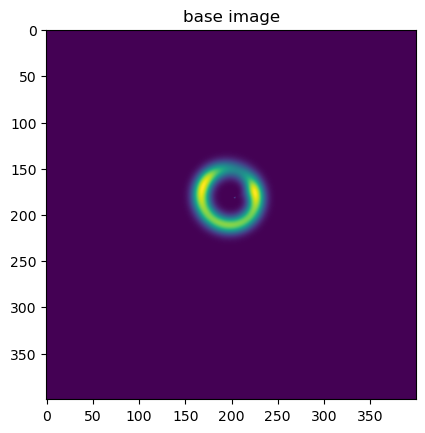

The PthPSF is loaded as it is. All the physical considerations must be done building it.


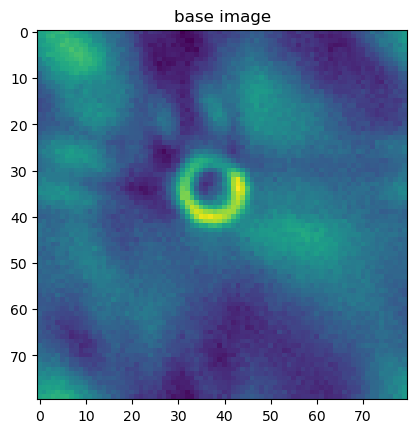

The PthPSF is loaded as it is. All the physical considerations must be done building it.


100%|██████████| 88/88 [00:12<00:00,  7.06it/s]


In [9]:
eval_grid=_grid_lens(8.0, 80, device="cuda")

a=SensMapMaker(sample_index = 7, evaluation_grid = eval_grid, upsampling = 5)


/tmp/ipykernel_83344/1021096108.py:249: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(torch.log10(self.values_key))


mass_thres shape: (80, 80)


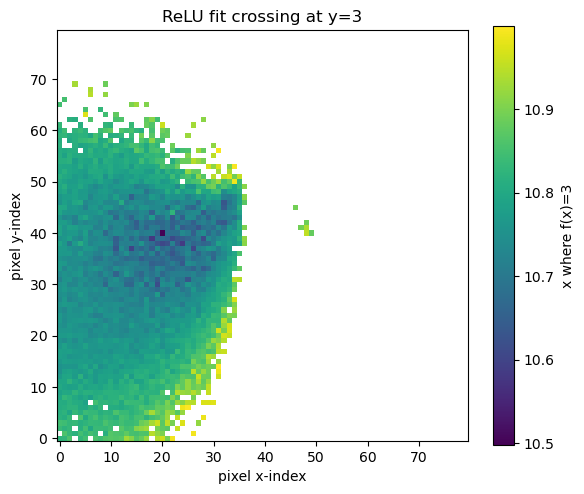

In [10]:
a.get_sensitivity_map(threshold=3)

In [7]:
#a.get_average_sensitivity_map( threshold=3, n_runs=5, plot_individual=True, plot_std=True)

In [8]:
# eval_grid=_grid_lens(8.0, 80, device="cuda")

# b=SensMapMaker(sample_index = 2, evaluation_grid = eval_grid, upsampling = 5)
# b.get_average_sensitivity_map( threshold=3, n_runs=5, plot_individual=True, plot_std=True)

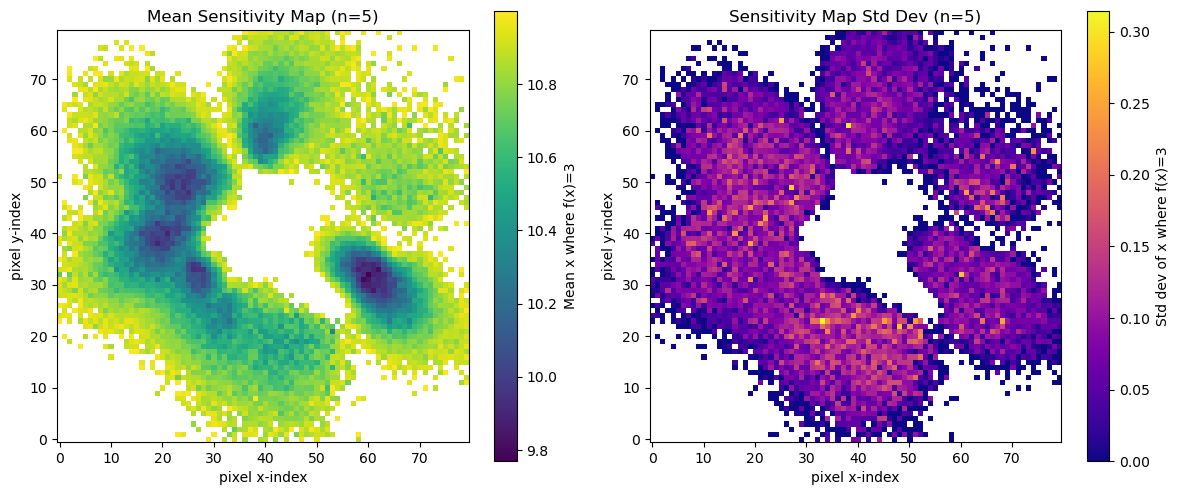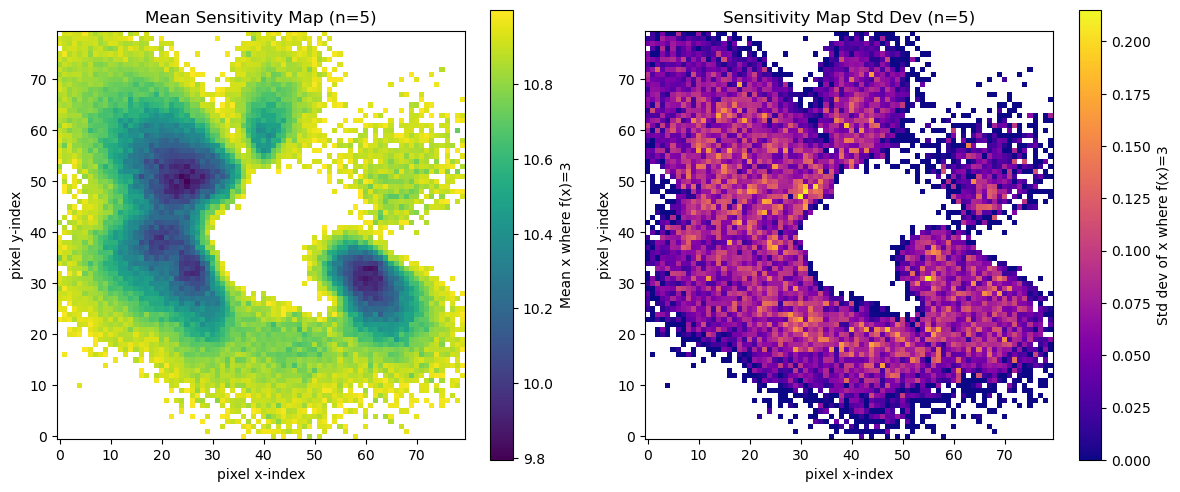